In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

In [45]:
df = pd.read_csv('income.csv')
df.head()

,Name,Age,Income($)
0,Rob,27,70000
1,Michael,29,90000
2,Mohan,29,61000
3,Ismail,28,60000
4,Kory,42,150000


In [46]:
df.describe()

,Age,Income($)
count,22.000000,22.000000
mean,34.818182,90431.818182
std,5.901060,43505.964412
min,26.000000,45000.000000
25%,29.000000,58500.000000
50%,36.500000,67500.000000
75%,39.750000,135250.000000
max,43.000000,162000.000000


### Scaling the Data

Scaling is important when using K-Means clustering because the algorithm is based on distance calculations, and when some features are larger than others, it can disproportionatly influence the result. Scaling the data ensures that all features in the data contributes equally to the final result.

In [47]:
min_age, max_age = min(df['Age']), max(df['Age'])
min_income, max_income = min(df['Income($)']), max(df['Income($)'])

diff_age = max_age - min_age
diff_income = max_income - min_income

df['Scaled age'] = (df['Age'] - min_age) / diff_age
df['Scaled income'] = (df['Income($)'] - min_income) / diff_income

df = df.drop(['Name', 'Age', 'Income($)'], axis = 1)
df.head()

,Scaled age,Scaled income
0,0.058824,0.213675
1,0.176471,0.384615
2,0.176471,0.136752
3,0.117647,0.128205
4,0.941176,0.897436


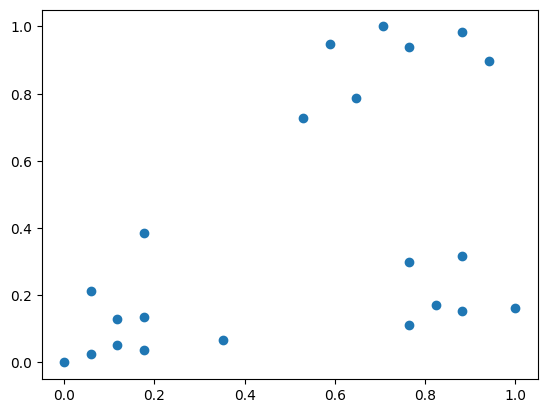

In [48]:
plt.scatter(df['Scaled age'], df['Scaled income'])
plt.show()

### Finding Optimal K

In [49]:
K_based_inertia = []
K_range = range(1, 10)

for k in K_range:
    model = KMeans(n_clusters = k, n_init = 10).fit(df)
    K_based_inertia.append(model.inertia_)

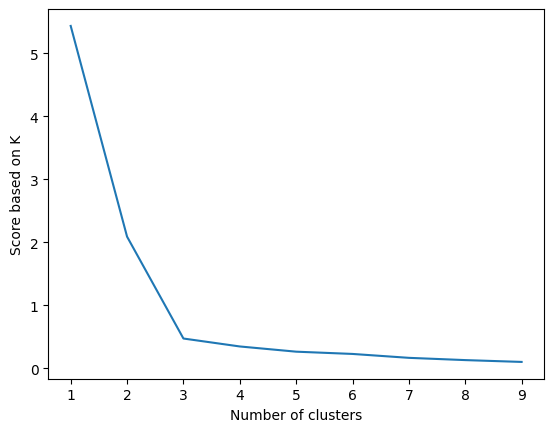

In [50]:
plt.plot(K_range, K_based_inertia)
plt.xlabel('Number of clusters')
plt.ylabel('Score based on K')
plt.show()

The optimal number of clusters is 3 based on the elbow diagram above.

### Defining the Clusters

In [51]:
model = KMeans(n_clusters = 3, n_init = 10).fit(df)

In [52]:
model.get_params()

{'algorithm': 'lloyd',
 'copy_x': True,
 'init': 'k-means++',
 'max_iter': 300,
 'n_clusters': 3,
 'n_init': 10,
 'random_state': None,
 'tol': 0.0001,
 'verbose': 0}

In [53]:
df['Cluster'] = model.predict(df)
df.head()

,Scaled age,Scaled income,Cluster
0,0.058824,0.213675,1
1,0.176471,0.384615,1
2,0.176471,0.136752,1
3,0.117647,0.128205,1
4,0.941176,0.897436,0


In [54]:
centers = model.cluster_centers_
pd.DataFrame(centers).rename(columns = {0: 'x', 1: 'y'})

,x,y
0,0.722689,0.897436
1,0.137255,0.116334
2,0.852941,0.202279


### Plotting the Clusters

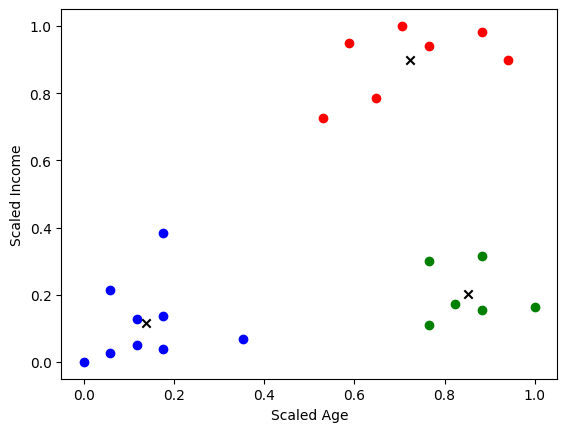

In [55]:
df0 = df[df['Cluster'] == 0]
df1 = df[df['Cluster'] == 1]
df2 = df[df['Cluster'] == 2]

plt.scatter(df0['Scaled age'], df0['Scaled income'], color = 'Red')
plt.scatter(df1['Scaled age'], df1['Scaled income'], color = 'Blue')
plt.scatter(df2['Scaled age'], df2['Scaled income'], color = 'Green')

plt.scatter(centers[:, 0], centers[:, 1], color = 'Black', marker = 'x')

plt.xlabel('Scaled Age')
plt.ylabel('Scaled Income')
plt.show()